In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ESCENARIO 1 (phi3:mini)

# Estilo de los gráficos
sns.set_theme(style="whitegrid")

# Cargar los DataFrames
df_raw_c = pd.read_csv('../results/escenario1_resultados_raw_completo.csv')
df_raw_r = pd.read_csv('../results/escenario1_resultados_raw_reducido.csv')
df_json_r = pd.read_csv('../results/escenario1_resultados_json_reducido.csv')

# Agregar una columna para identificar de dónde viene cada dato
df_raw_c['Formato'] = 'RAW Completo'
df_raw_r['Formato'] = 'RAW Reducido'
df_json_r['Formato'] = 'JSON Reducido'

# Unir todo en un único DataFrame
df_total = pd.concat([df_raw_c, df_raw_r, df_json_r], ignore_index=True)

# Asegurar el orden categórico de los riesgos
orden_riesgo = ['INFO', 'BAJO', 'MEDIO', 'ALTO', 'INFORMACIÓN', 'ERROR_PARSE']



In [6]:
mean_tr_rawr = df_raw_r[df_raw_r['Tiempo Respuesta (s)'] != 0.0]['Tiempo Respuesta (s)'].mean()
print(mean_tr_rawr)

mean_tr_rawc = df_raw_c[df_raw_c['Tiempo Respuesta (s)'] != 0.0]['Tiempo Respuesta (s)'].mean()
print(mean_tr_rawc)

mean_tr_jsonr = df_json_r[df_json_r['Tiempo Respuesta (s)'] != 0.0]['Tiempo Respuesta (s)'].mean()
print(mean_tr_jsonr)

5.905
6.145107913669065
6.895285714285714


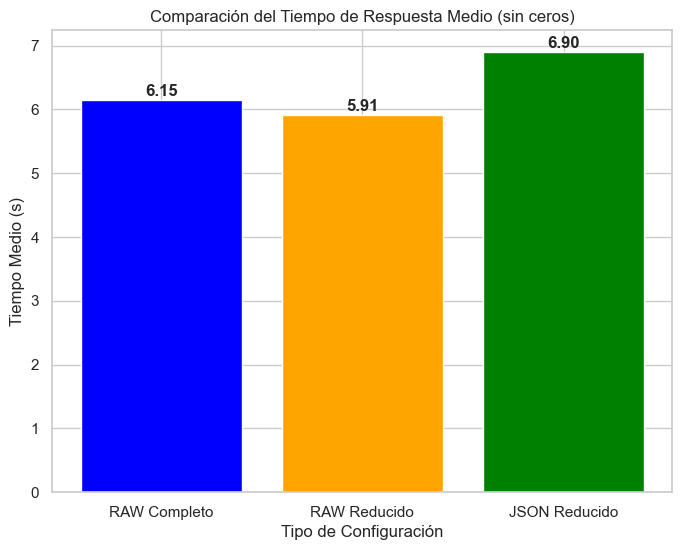

In [7]:
# --- 2. PREPARAR LOS DATOS PARA EL GRÁFICO ---
# Creamos una lista con las etiquetas (los nombres de las barras)
etiquetas = ['RAW Completo','RAW Reducido','JSON Reducido']
# Creamos una lista con los valores numéricos correspondientes
valores_medias = [mean_tr_rawc, mean_tr_rawr, mean_tr_jsonr]

# --- 3. CREAR EL BAR PLOT CON MATPLOTLIB ---
# Creamos la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 6))  # Tamaño opcional

# Dibujamos las barras (x=etiquetas, y=valores)
ax.bar(etiquetas, valores_medias, color=['blue', 'orange', 'green'])

# --- 4. PERSONALIZAR EL GRÁFICO (RECOMENDADO) ---
# Título y etiquetas de los ejes
ax.set_title('Comparación del Tiempo de Respuesta Medio (sin ceros)')
ax.set_ylabel('Tiempo Medio (s)')
ax.set_xlabel('Tipo de Configuración')

# Opcional: Mostrar el valor numérico exacto encima de cada barra
for i, v in enumerate(valores_medias):
    # ax.text(x, y, string, ha='center')
    ax.text(i, v + (max(valores_medias) * 0.01), f"{v:.2f}", ha='center', fontweight='bold')

# --- 5. MOSTRAR O GUARDAR EL GRÁFICO ---
# Para mostrarlo en una ventana (si estás en local) o Notebook:
plt.show()

In [ ]:
# ==========================================
# Gráfico 1: Distribución de Riesgos
# ==========================================
plt.figure(figsize=(10, 6))
# countplot cuenta automáticamente las ocurrencias en la columna 'Riesgo'
ax = sns.countplot(
    data=df_total, 
    x='Formato', 
    hue='Riesgo', 
    hue_order=orden_riesgo,
    palette=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', 'purple', 'yellow']
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title('Distribución de Clasificación de Riesgo por Formato (Escenario 1 - phi3:mini)', fontsize=14, pad=15)
plt.xlabel('Formato de Entrada', fontsize=12)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.legend(title='Nivel de Riesgo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Guardar la imagen
plt.savefig('../results/charts/grafico_distribucion_escenario1.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Gráfico 2: Tiempo Promedio de Respuesta
# ==========================================
plt.figure(figsize=(8, 5))

# barplot calcula el promedio automáticamente
ax = sns.barplot(
    data=df_total, 
    x='Formato', 
    y='Tiempo Respuesta (s)',
    hue='Formato',
    legend=False, 
    errorbar=None,
    palette='Blues_d'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f s', fontsize=10, padding=3)

plt.title('Tiempo Promedio de Respuesta por Formato (Escenario 1 - phi3:mini)', fontsize=14, pad=15)
plt.xlabel('Formato de Entrada', fontsize=12)
plt.ylabel('Tiempo Promedio (Segundos)', fontsize=12)

# Guardar la imagen
plt.savefig('../results/grafico_tiempos_escenario1.png', dpi=300, bbox_inches='tight')
plt.show()